# Linear regression

In [70]:
import pandas as pd # for reading the dataset from the csv file
import numpy as np # for test train val split
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression # Model
from sklearn.metrics import classification_report # classification report

Reading data set

In [71]:
df = pd.read_csv("/content/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Spliting dataset

In [72]:
def get_xy(df):
  return df.drop(columns="Outcome"), df["Outcome"]

train, val, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))]) # Spliting dataset
x_train, y_train = get_xy(train) # Getting x, y train
x_test, y_test = get_xy(test) # Getting x, y test

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Model

In [73]:
linear_model = LinearRegression() # model
linear_model.fit(x_train, y_train) # Train a pretrained model on my dataset

LinearRegression()

Prediction

In [74]:
prediction = linear_model.predict(x_test) # Make prediction
prediction = (prediction > 0.5).astype(int) # if the prediction is greater then 0.5 make it 1 else 0
print(classification_report(y_test, prediction)) # Print the accuracy, precision, recall etc.

              precision    recall  f1-score   support

           0       0.81      0.84      0.83       102
           1       0.67      0.62      0.64        52

    accuracy                           0.77       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.77      0.76       154



Ploting

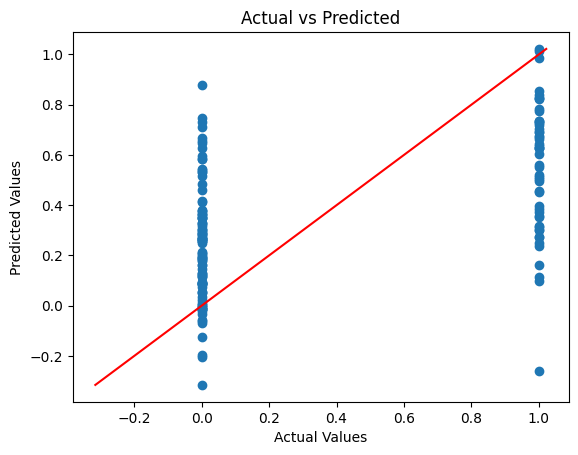

In [77]:
y_pred =  linear_model.predict(x_test)
plt.scatter(y_test, y_pred)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r-", label="Perfect Prediction")
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.show()